In [1]:
# !pip install sgp4
# !pip install pymap3d

ali
Hotspot center: [ 860.91572333 1051.16685748]


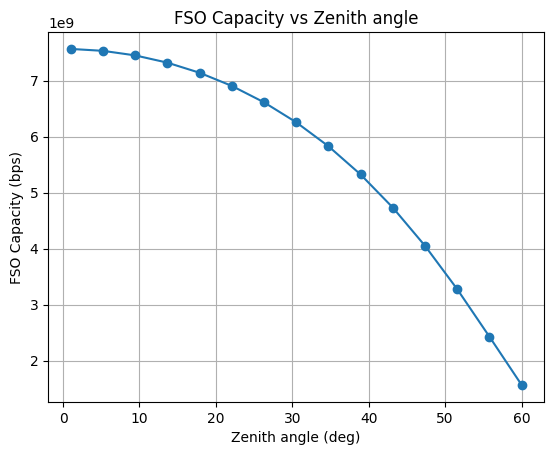

d:\chuyende2\SAGIN-problem-optimization


In [2]:
from model.HAP import *
from model.UAV import *
from network_models.users import *
from network_models.cloud_model import *
from network_models.parameters import *
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import trange
import random
from network_models.multi_sat import *
from satellite.satellite_model import *

In [7]:
# -----------------------------
# Tham số chung
# -----------------------------
EPS_START = 1
EPS_END = 0.05
EXPLORE_PERCENT = 0.75
EPISODES = 300
STEP_PER_EPISODE = 300
EPS_DECAY = (EPS_START - EPS_END) / (EPISODES * STEP_PER_EPISODE * EXPLORE_PERCENT)
gamma = 0.99
num_uav = 3

device = "cuda" if torch.cuda.is_available() else "cpu"
Q_nets_UAV = [QNetwork_UAV(142, 5).to(device) for _ in range(num_uav)]
target_Q_nets_UAV = [QNetwork_UAV(142, 5).to(device) for _ in range(num_uav)]

for i in range(num_uav):
    target_Q_nets_UAV[i].load_state_dict(Q_nets_UAV[i].state_dict())
    for param in target_Q_nets_UAV[i].parameters():
        param.requires_grad = False

optimizers_uav = [optim.AdamW(Q_nets_UAV[i].parameters(), lr=0.001, amsgrad=True) for i in range(num_uav)]
replay_buffers_uav = [ReplayMemory(capacity=1000000, obs_dim=142) for _ in range(num_uav)]
HAP_position = np.array([area_size / 2, area_size / 2, H_atm], dtype=np.float32)

# HAP network
Q_nets_HAP = QNetwork_HAP(63, 30).to(device)
target_Q_nets_HAP = QNetwork_HAP(63, 30).to(device)
target_Q_nets_HAP.load_state_dict(Q_nets_HAP.state_dict())

optimizers_hap = optim.AdamW(Q_nets_HAP.parameters(), lr=0.001, amsgrad=True)
scheduler = optim.lr_scheduler.StepLR(optimizers_hap, step_size=200, gamma=0.9)  # 🔧 thêm scheduler

# for _ in range(1500):  # vì đã train 1500 ep
#     scheduler.step()
    
replay_buffers_hap = ReplayMemory_HAP(capacity=1000000, obs_dim=63)

# steps_done = 1500*300
steps_done = 0
episode_return_uav = []
episode_return_hap = []

In [ ]:
for episode in trange(2500):
    cloud_map = get_full_cloud_torch().squeeze().cpu().numpy()
    user_positions = simulate_user_mobility_2(200, STEP_PER_EPISODE+1)

    uav_pos = np.zeros((num_uav, 3), dtype=np.float32)
    num_cells_x = 10  # 1500 / 150 ≈ 10
    num_cells_y = 8   # 1500 / 187.5 ≈ 8
    cell_size_x = area_size / num_cells_x  # 150
    cell_size_y = area_size / num_cells_y  # 187.5
    for i in range(num_uav):
        cell_idx = np.random.randint(0, 76)  # Rand from 0 to 75
        cell_x = (cell_idx % num_cells_x) * cell_size_x + cell_size_x / 2
        cell_y = (cell_idx // num_cells_x) * cell_size_y + cell_size_y / 2
        uav_pos[i, 0] = cell_x
        uav_pos[i, 1] = cell_y
        uav_pos[i, 2] = H_OGS

    actions_uav = []
    alpha, beta = None, None
    sat_per_step = get_random_300(data, n_steps=STEP_PER_EPISODE+1)
    prev_satellite_id = None

    # init alpha, beta, C_FSO_UAV_before
    region_t, clwc_map_t, new_cloud = get_clwc_map(cloud_map)

    _, alpha, beta, _, C_FSO_UAV_before = user_association_and_reward_opti(
        uav_pos, user_positions[:,0,:], region_t, HAP_position, actions_uav, 0, device
    )
    total_hap_reward = 0
    total_uav_reward = np.zeros(3)

    handover_count = 0

    for t in range(STEP_PER_EPISODE):
        steps_done += 1
        region_t, clwc_map_t, new_cloud = get_clwc_map(cloud_map)
        cloud_map = new_cloud
        user_pos_t = user_positions[:, t, :]
        epsilon = max(EPS_END, EPS_START - EPS_DECAY * steps_done)
        # U_sum = np.sum(C_FSO_UAV_before)

        obs_hap, top_list, feasible = build_observation_hap(t, sat_per_step, C_FSO_UAV_before/(1.4e10), prev_satellite_id)
        obs_hap = torch.tensor(obs_hap, dtype=torch.float32, device=device)
        if(episode == 0 and t == 2):
            print(obs_hap)
        
        action_idx, current_satellite_id, keep_idx = select_action_topk(top_list, Q_nets_HAP, obs_hap, prev_satellite_id, epsilon)

        # check safe index
        if action_idx is None or action_idx < 0 or action_idx >= len(top_list):
            sat_name, elev, vt, slant, c_fso = None, 0, 0, 0, 0
        else:
            sat_name, elev, vt, slant, c_fso,_ = top_list[action_idx]

        sat_info = {'sat_name': sat_name, 'elev': elev, 'vt': vt, 'slant': slant, 'c_fso': c_fso}
        U_sum = np.sum(C_FSO_UAV_before)
        reward_hap = hap_reward_2(sat_info['c_fso']*(1.4e10), U_sum, action_idx, sat_info['vt'], feasible)
        total_hap_reward += reward_hap

        obs_uav = build_observations_vector_2(uav_pos, user_pos_t, clwc_map_t, alpha, beta).to(device)
        with torch.no_grad():
                    actions_uav = [
                        random.randint(0, 5 - 1) if random.random() < epsilon
                        else Q_nets_UAV[i](obs_uav[i].unsqueeze(0)).argmax().item()
                        for i in range(num_uav)
                    ]
            
        uav_pos = move_uavs(uav_pos, actions_uav)
        next_region_t, next_clwc_map_t, new_cloud = get_clwc_map(cloud_map)
        next_user_pos_t = user_positions[:, t+1, :]

        rewards_uav, alpha, beta, _, C_FSO_UAV_after = user_association_and_reward_opti(
            uav_pos, next_user_pos_t, next_region_t, HAP_position, actions_uav, t, device
        )
        total_uav_reward += rewards_uav

        # prev_valid for next step
        next_top_list = sat_per_step.get(t+1, [])
        prev_valid_for_next = False
        if current_satellite_id is not None:
            prev_valid_for_next = any(s[0] == current_satellite_id for s in next_top_list)

        next_obs_hap, top_list_next,_ = build_observation_hap(t+1, sat_per_step, C_FSO_UAV_after/(1.4e10), current_satellite_id)
        next_obs_hap = torch.tensor(next_obs_hap, dtype=torch.float32, device=device)
        next_obs_uav = build_observations_vector_2(uav_pos, next_user_pos_t, next_clwc_map_t, alpha, beta)

        # giả sử bạn có top_list_next ở step tiếp theo
        n_valid_next = len(top_list_next)
        done = 0
        if(t == 299):
            done = 1
        replay_buffers_hap.push(
            obs_hap.cpu().numpy(),
            action_idx,
            reward_hap,
            next_obs_hap.cpu().numpy(),
            done,  # done = 0 vì episode fixed length
            n_valid_next
        )
        for i in range(3):
            replay_buffers_uav[i].push(obs_uav[i], actions_uav[i], rewards_uav[i], next_obs_uav[i], done)
            
        # handover count
        if prev_satellite_id is not None and current_satellite_id is not None and prev_satellite_id != current_satellite_id:
            handover_count += 1

        C_FSO_UAV_before = C_FSO_UAV_after
        prev_satellite_id = current_satellite_id
        #train UAV
        tau = 0.005
        for i in range(3):
            if len(replay_buffers_uav[i]) >= 64:
                # Sample minibatch
                states, actions_batch, rewards_batch, next_states, dones_batch = replay_buffers_uav[i].sample(64)
                
                # Calculate target Q
                with torch.no_grad():
                    max_next_q = target_Q_nets_UAV[i](next_states).max(1).values
                    target_q = rewards_batch + gamma * (1 - dones_batch) * max_next_q
                
                # Current Q
                current_q = Q_nets_UAV[i](states).gather(1, actions_batch).squeeze()
                
                # Huber Loss
                loss = nn.SmoothL1Loss()(current_q, target_q)
                
                # Gradient descent
                optimizers_uav[i].zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_value_(Q_nets_UAV[i].parameters(), 1.0)
                optimizers_uav[i].step()
                
                # Soft update
                target_state_dict = target_Q_nets_UAV[i].state_dict()
                policy_state_dict = Q_nets_UAV[i].state_dict()
                for key in policy_state_dict:
                    target_state_dict[key] = tau * policy_state_dict[key] + (1 - tau) * target_state_dict[key]
                target_Q_nets_UAV[i].load_state_dict(target_state_dict)
                
        # train HAP
        hap_device = next(Q_nets_HAP.parameters()).device
        BATCH = 128
        if len(replay_buffers_hap) >= BATCH:
            idxs, states_np, actions_np, rewards_np, next_states_np, dones_np, n_valids_np = replay_buffers_hap.sample(BATCH)
        
            states = torch.tensor(states_np, dtype=torch.float32, device=hap_device)
            actions = torch.tensor(actions_np, dtype=torch.long, device=hap_device)
            rewards = torch.tensor(rewards_np, dtype=torch.float32, device=hap_device)
            next_states = torch.tensor(next_states_np, dtype=torch.float32, device=hap_device)
            dones = torch.tensor(dones_np, dtype=torch.float32, device=hap_device)
            n_valids = torch.tensor(n_valids_np, dtype=torch.long, device=hap_device)
        
            # Q(s,a)
            q_values = Q_nets_HAP(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        
            with torch.no_grad():
                q_next_all = target_Q_nets_HAP(next_states)  # [B, action_space]
                neg_inf = -1e9
                action_space = q_next_all.shape[1]
        
                idxs_range = torch.arange(action_space, device=hap_device).unsqueeze(0).expand(len(n_valids), -1)
                valid_mask = idxs_range < n_valids.unsqueeze(1)
                q_next_all[~valid_mask] = neg_inf
        
                max_next_q = q_next_all.max(dim=1).values
                target_q = rewards + gamma * (1 - dones) * max_next_q
        
            loss = nn.SmoothL1Loss()(q_values, target_q)
            optimizers_hap.zero_grad()
            loss.backward()
            optimizers_hap.step()

        tau = 0.005
        for target_param, param in zip(target_Q_nets_HAP.parameters(), Q_nets_HAP.parameters()):
            target_param.data.copy_(tau * param.data + (1.0 - tau) * target_param.data)
    
    episode_return_hap.append(total_hap_reward)
    episode_return_uav.append(total_uav_reward)
    scheduler.step()   # 🔧 update learning rate

    print(f"Episode {episode}, HAP reward: {total_hap_reward:.2f}, UAV reward: {total_uav_reward}, handovers: {handover_count}, epsilon: {epsilon:.4f}")

    if (episode+1) in [1000]:
        save_dir = "/kaggle/working/"
        torch.save(Q_nets_HAP.state_dict(), os.path.join(save_dir, f"HAP_ep{episode+1}.pth"))
        print(f"✅ Saved HAP model & rewards at episode {episode+1}")
        for i in range(num_uav):
            torch.save(Q_nets_UAV[i].state_dict(), os.path.join(save_dir, f"UAV{i}_ep{episode+1}.pth"))
            torch.save(target_Q_nets_UAV[i].state_dict(), os.path.join(save_dir, f"UAV{i}_target_ep{episode+1}.pth"))
        for i, opt in enumerate(optimizers_uav):
            torch.save(opt.state_dict(), os.path.join(save_dir, f"optimizer_uav{i}_ep{episode+1}.pth"))
        torch.save(optimizers_hap.state_dict(), os.path.join(save_dir, f"optimizer_hap_ep{episode+1}.pth"))


        for i, buf in enumerate(replay_buffers_uav):
            with open(os.path.join(save_dir, f"replay_uav{i}_ep{episode+1}.pkl"), "wb") as f:
                pickle.dump(buf, f)

        with open(os.path.join(save_dir, f"replay_hap_ep{episode+1}.pkl"), "wb") as f:
            pickle.dump(replay_buffers_hap, f)

        print(f"✅ Saved models, optimizers, rewards, and buffers at episode {episode+1}")

        
    episode_return_hap.append(total_hap_reward)
    episode_return_uav.append(total_uav_reward)

  0%|          | 0/1010 [00:00<?, ?it/s]

tensor([0.2200, 0.2800, 0.0733, 0.7533, 0.4333, 0.5267, 0.3667, 0.6467, 0.5067,
        0.6600, 0.9533, 0.5400, 0.4467, 0.8067, 0.0333, 0.3333, 0.4800, 0.0733,
        0.1067, 0.4467, 0.0800, 0.0800, 0.2600, 0.6600, 0.1667, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.4694, 0.5748, 0.3221, 0.4976, 0.6406, 0.4798,
        0.5598, 0.5963, 0.6377, 0.6682, 0.2973, 0.5197, 0.3998, 0.5037, 0.3188,
        0.6565, 0.7205, 0.3317, 0.3670, 0.6839, 0.3942, 0.3912, 0.6647, 0.3893,
        0.5825, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0574, 0.0138, 0.1070],
       device='cuda:0')


  0%|          | 1/1010 [00:51<14:23:15, 51.33s/it]

Episode 1500, HAP reward: -11105.00, UAV reward: [ -84.41845042 -203.85672245  -85.10967469], handovers: 282, epsilon: 0.9958


  0%|          | 1/1010 [01:16<21:19:47, 76.10s/it]


KeyboardInterrupt: 